# 01 - Part A: recovering an arbitrary rotation angle

> *"Read the above image, rotate it by an arbitrary angle, and compute the angle
> of rotation using object detection, given the reference angle shown above
> (circle at top left)."*

The prompt tells us what the marker is for: the circle is the **reference
angle**. A square is invariant under quarter turns, so the square alone can only
ever give the angle modulo 90 deg. The circle breaks that ambiguity, and the
square's long, straight, heavily-sampled edges then refine it.

Contents: candidate approaches -> chosen approach -> the sign, derived and
verified -> results -> robustness -> the long-edge experiment -> limitations.

In [1]:
# --- Colab / local bootstrap -------------------------------------------------
# Works unchanged in Colab and on a local machine: walk up from the working
# directory until the package is found; in Colab, mount Drive first.
import os, sys

def _find_root(start=None):
    p = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(p, "src", "aulecv")):
            return p
        nxt = os.path.dirname(p)
        if nxt == p:
            return None
        p = nxt

PROJECT_ROOT = _find_root()
if PROJECT_ROOT is None and "google.colab" in sys.modules:      # pragma: no cover
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/AULE_ComputerVisionChallenge"
    if not os.path.isdir(os.path.join(PROJECT_ROOT, "src", "aulecv")):
        raise RuntimeError("put the project folder at " + PROJECT_ROOT)
if PROJECT_ROOT is None:
    raise RuntimeError("could not locate the project root")

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


In [2]:
reference = aio.load_reference()
ref_det = detect.detect_port(reference)
print("reference detection confidence :", round(ref_det.confidence, 4))
print("reference marker polar angle   : {:.4f} deg (image axes, y down)"
      .format(ref_det.marker_angle_from_center_deg))
print("reference edge angle mod 90    : {:.4f} deg".format(ref_det.edge_angle_mod90_deg()))

reference detection confidence : 0.9385
reference marker polar angle   : -138.6431 deg (image axes, y down)
reference edge angle mod 90    : 0.0000 deg


## 1. Candidate approaches

| Approach | Range | Verdict |
|---|---|---|
| Brute-force template matching over rotated copies | full 360 deg | Rejected as the primary method: O(n) warps per query, accuracy limited by the angular sampling step, and it needs the reference image at query time. |
| PCA / image moments of the foreground mask | mod 180 deg | Rejected: the port is very nearly square, so the second moment matrix is nearly isotropic and its eigenvectors are numerically unstable. |
| `minAreaRect` angle | mod 90 deg | Rejected alone (ambiguous), and it uses only the extreme points. |
| Square edge directions (`fitLine` per side) | mod 90 deg | **Kept as the refinement**: hundreds of edge samples per side, sub-pixel, very precise -- but ambiguous. |
| Centre -> marker vector | **full 360 deg** | **Kept as the coarse estimate**: unambiguous, but its precision is limited by how well the marker centroid is localised. |
| Keypoints (ORB/SIFT) + `estimateAffinePartial2D` | full 360 deg | Viable, but overkill for a synthetic figure with four textureless flat regions; ORB finds most of its keypoints on the same few corners. |

**Chosen: fuse the two kept cues.** Coarse (unambiguous) from the marker, then
snap to the nearest 90 deg-equivalent of the precise edge estimate. This gets the
full range *and* the precision, and it degrades gracefully: if the two disagree
by more than `config.ROTATION_REFINE_TOL_DEG` the refinement is refused and the
marker-only answer is returned with a note.

## 2. The sign convention, derived and then verified

`cv2.getRotationMatrix2D(c, a, 1)` has, in image axes (x right, y **down**),

$$ M = \begin{bmatrix} \cos a & \sin a & \cdot \\ -\sin a & \cos a & \cdot \end{bmatrix} $$

A point at polar angle $\theta=\operatorname{atan2}(y-c_y,\;x-c_x)$ goes to

$$ \operatorname{atan2}(-s x + c y,\; c x + s y) = \theta - a $$

so **image-space polar angles decrease by $a$** (which is exactly why a positive
$a$ looks counter-clockwise on a screen whose $y$ points down). Therefore

$$ a = \theta_{\text{ref}} - \theta_{\text{rotated}} \pmod{360^\circ} $$

and, applying the same argument to the quad's side directions,
$a \equiv \varphi_{\text{ref}} - \varphi_{\text{rotated}} \pmod{90^\circ}$.

Rather than trust that derivation, verify it against OpenCV:

In [3]:
centre = np.array([137.0, 61.0])
print("   a        theta0     theta1    theta0-theta1")
for a in (10.0, 45.0, 123.0, 250.0, 359.0):
    M = cv2.getRotationMatrix2D(tuple(centre), a, 1.0)
    p = centre + np.array([80.0, 0.0])
    q = M @ np.array([p[0], p[1], 1.0])
    th0 = np.degrees(np.arctan2(p[1] - centre[1], p[0] - centre[0]))
    th1 = np.degrees(np.arctan2(q[1] - centre[1], q[0] - centre[0]))
    print("{:7.2f}  {:9.4f}  {:9.4f}   {:9.4f}".format(a, th0, th1, rotation.wrap360(th0 - th1)))
print("\nthe last column reproduces `a` exactly -> the derived sign is correct")

   a        theta0     theta1    theta0-theta1
  10.00     0.0000   -10.0000     10.0000
  45.00     0.0000   -45.0000     45.0000
 123.00     0.0000  -123.0000    123.0000
 250.00     0.0000   110.0000    250.0000
 359.00     0.0000     1.0000    359.0000

the last column reproduces `a` exactly -> the derived sign is correct


## 3. Results on the requested angles

`rotate_image` expands the canvas so nothing is clipped and fills the new area
with the page background sampled from the image border, so the detector's
background estimate still works on the rotated image.

In [4]:
ANGLES = [0.0, 7.5, 23.0, 45.0, 90.0, 137.25, 180.0, 222.5, 270.0, 313.7, 359.0]

rows, panels, titles = [], [], []
for a in ANGLES:
    img = rotation.rotate_image(reference, a)
    est = rotation.estimate_rotation(img, ref_det)
    rows.append({
        "true_deg": a,
        "estimated_deg": round(est.angle_deg, 4),
        "error_deg": round(rotation.angular_error(est.angle_deg, a), 4),
        "marker_only_deg": round(est.marker_angle_deg, 4),
        "marker_only_err": round(rotation.angular_error(est.marker_angle_deg, a), 4),
        "edge_mod90_deg": round(est.edge_angle_mod90_deg, 4),
        "refined": est.refined,
        "residual_deg": round(est.residual_deg, 4),
        "confidence": round(est.confidence, 3),
        "status": est.status,
    })
    panels.append(viz.draw_detection(img, est.detection, label_corners=False))
    titles.append("true {:g} deg\nest {:.3f} deg".format(a, est.angle_deg))

results = pd.DataFrame(rows)
display(results)
print("\nMEASURED on these {} angles:".format(len(ANGLES)))
print("  fused      MAE {:.4f} deg   max |err| {:.4f} deg"
      .format(results['error_deg'].abs().mean(), results['error_deg'].abs().max()))
print("  marker only MAE {:.4f} deg   max |err| {:.4f} deg"
      .format(results['marker_only_err'].abs().mean(), results['marker_only_err'].abs().max()))

,true_deg,estimated_deg,error_deg,marker_only_deg,marker_only_err,edge_mod90_deg,refined,residual_deg,confidence,status
0,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,True,0.0000,0.938,ok
1,7.50,7.5010,0.0010,7.4999,-0.0001,7.5010,True,0.0011,0.938,ok
2,23.00,22.9998,-0.0002,23.0090,0.0090,22.9998,True,0.0092,0.938,ok
3,45.00,45.0000,0.0000,45.0555,0.0555,45.0000,True,0.0555,0.938,ok
4,90.00,90.0000,-0.0000,89.9963,-0.0037,90.0000,True,0.0037,0.907,ok
5,137.25,137.2491,-0.0009,137.2474,-0.0026,47.2491,True,0.0017,0.938,ok
6,180.00,180.0000,-0.0000,179.9351,-0.0649,90.0000,True,0.0649,0.921,ok
7,222.50,222.5011,0.0011,222.5377,0.0377,42.5011,True,0.0366,0.927,ok
8,270.00,270.0000,-0.0000,269.9290,-0.0710,90.0000,True,0.0710,0.920,ok
9,313.70,313.7018,0.0018,313.6816,-0.0184,43.7018,True,0.0201,0.908,ok



MEASURED on these 11 angles:
  fused      MAE 0.0008 deg   max |err| 0.0043 deg
  marker only MAE 0.0239 deg   max |err| 0.0710 deg


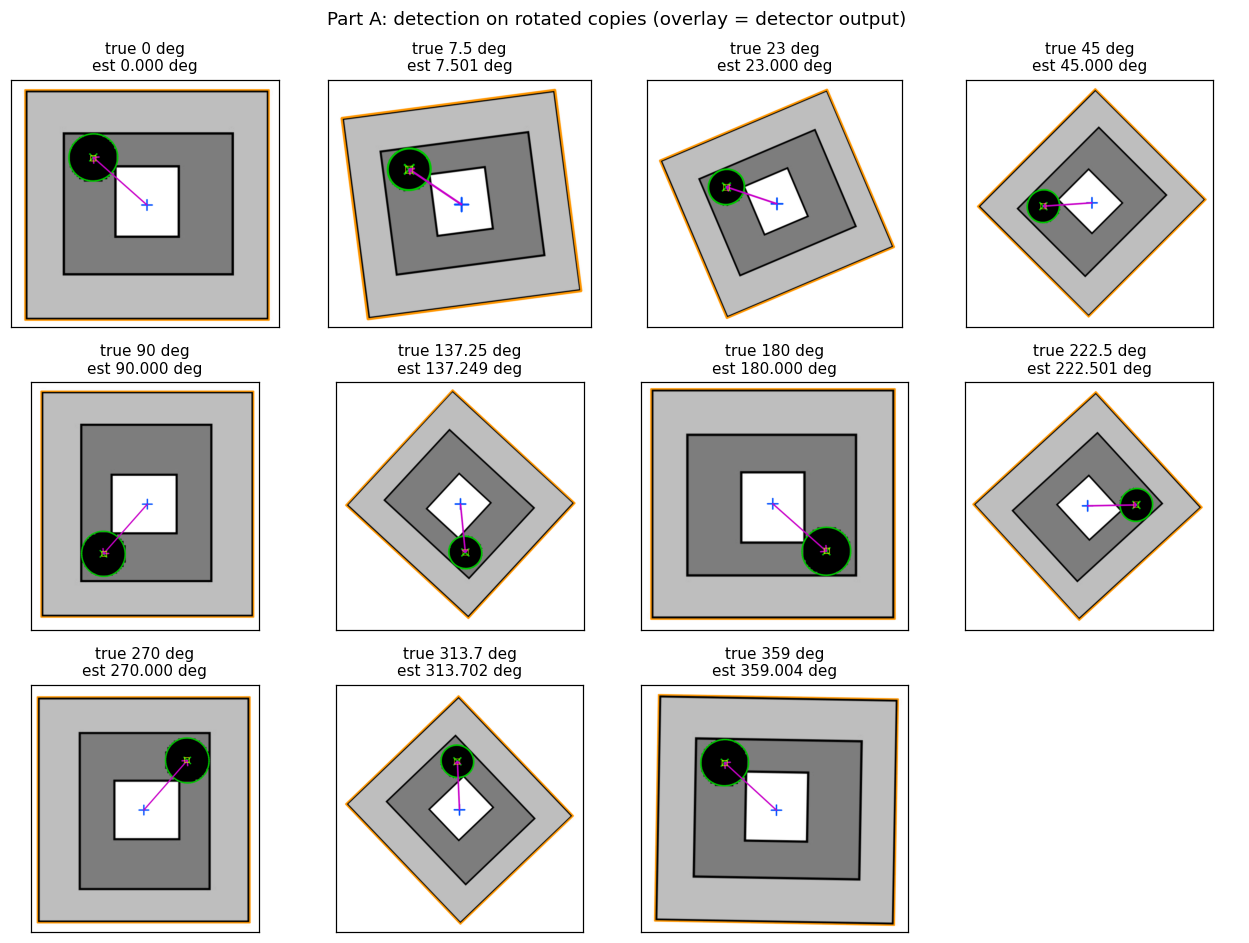

In [5]:
fig = viz.grid(panels, titles, cols=4, figsize_per=2.9,
               suptitle="Part A: detection on rotated copies (overlay = detector output)")
fig.savefig(aio.output_path("rotation_tests", "requested_angles.png"),
            bbox_inches="tight", dpi=110)
plt.show()

## 4. Why the square alone is not enough

Four angles that differ by exactly 90 deg produce *identical* square geometry.
The estimator must still tell them apart -- and it does, because the marker
vector is not quarter-turn symmetric.

In [6]:
rows = []
for a in (31.0, 121.0, 211.0, 301.0):
    d = detect.detect_port(rotation.rotate_image(reference, a))
    est = rotation.estimate_rotation_from_detections(d, ref_det)
    rows.append({"true_deg": a,
                 "square_cue_mod90": round(est.edge_angle_mod90_deg, 4),
                 "marker_cue_full_range": round(est.marker_angle_deg, 4),
                 "fused": round(est.angle_deg, 4),
                 "error_deg": round(rotation.angular_error(est.angle_deg, a), 4)})
amb = pd.DataFrame(rows)
display(amb)
print("The `square_cue_mod90` column is the same value four times -- that is the")
print("90 deg ambiguity. `marker_cue_full_range` separates them, and `fused`")
print("keeps the marker's branch with the square's precision.")

,true_deg,square_cue_mod90,marker_cue_full_range,fused,error_deg
0,31.0,31.0019,30.9933,31.0019,0.0019
1,121.0,31.0013,120.9860,121.0013,0.0013
2,211.0,31.0018,210.9938,211.0018,0.0018
3,301.0,31.0019,300.9862,301.0019,0.0019


The `square_cue_mod90` column is the same value four times -- that is the
90 deg ambiguity. `marker_cue_full_range` separates them, and `fused`
keeps the marker's branch with the square's precision.


## 5. Accuracy over the whole circle

In [7]:
sweep = []
for a in range(0, 360):
    est = rotation.estimate_rotation(rotation.rotate_image(reference, float(a)), ref_det)
    sweep.append({"true_deg": float(a), "estimated_deg": est.angle_deg,
                  "error_deg": rotation.angular_error(est.angle_deg, float(a)),
                  "marker_only_err": rotation.angular_error(est.marker_angle_deg, float(a)),
                  "refined": est.refined, "confidence": est.confidence,
                  "status": est.status})
sweep = pd.DataFrame(sweep)

rng = np.random.default_rng(C.RANDOM_SEED)
rand = []
for a in rng.uniform(0.0, 360.0, 200):
    est = rotation.estimate_rotation(rotation.rotate_image(reference, float(a)), ref_det)
    rand.append({"true_deg": float(a), "estimated_deg": est.angle_deg,
                 "error_deg": rotation.angular_error(est.angle_deg, float(a)),
                 "marker_only_err": rotation.angular_error(est.marker_angle_deg, float(a)),
                 "refined": est.refined, "confidence": est.confidence,
                 "status": est.status})
rand = pd.DataFrame(rand)

def _stats(df, name):
    e = df["error_deg"].abs()
    m = df["marker_only_err"].abs()
    return {"experiment": name, "n": len(df),
            "fused_MAE_deg": e.mean(), "fused_max_deg": e.max(),
            "fused_p99_deg": np.percentile(e, 99),
            "marker_only_MAE_deg": m.mean(), "marker_only_max_deg": m.max(),
            "refined_rate": df["refined"].mean(),
            "status_ok_rate": (df["status"] == "ok").mean(),
            "min_confidence": df["confidence"].min()}

acc = pd.DataFrame([_stats(sweep, "1 deg sweep, 0-359"),
                    _stats(rand, "200 seeded random angles")])
display(acc.round(5))
print()
print("TARGET (stated in the plan, before running): fused MAE < 0.3 deg, max < 1 deg.")
print("MEASURED: sweep MAE {:.4f} deg / max {:.4f} deg;  random MAE {:.4f} deg / max {:.4f} deg."
      .format(acc.loc[0, 'fused_MAE_deg'], acc.loc[0, 'fused_max_deg'],
              acc.loc[1, 'fused_MAE_deg'], acc.loc[1, 'fused_max_deg']))

,experiment,n,fused_MAE_deg,fused_max_deg,fused_p99_deg,marker_only_MAE_deg,marker_only_max_deg,refined_rate,status_ok_rate,min_confidence
0,"1 deg sweep, 0-359",360,0.00103,0.01044,0.01008,0.01566,0.07098,1.0,1.0,0.89117
1,200 seeded random angles,200,0.00108,0.01585,0.00622,0.01557,0.06823,1.0,1.0,0.88457



TARGET (stated in the plan, before running): fused MAE < 0.3 deg, max < 1 deg.
MEASURED: sweep MAE 0.0010 deg / max 0.0104 deg;  random MAE 0.0011 deg / max 0.0158 deg.


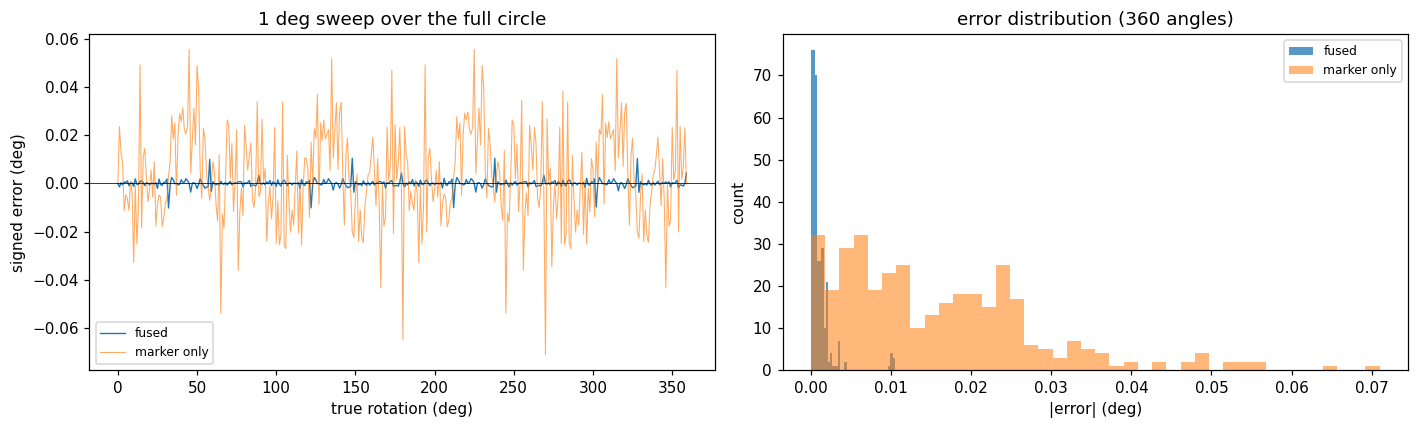

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
axes[0].plot(sweep["true_deg"], sweep["error_deg"], lw=0.9, label="fused")
axes[0].plot(sweep["true_deg"], sweep["marker_only_err"], lw=0.7, alpha=0.65, label="marker only")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel("true rotation (deg)"); axes[0].set_ylabel("signed error (deg)")
axes[0].set_title("1 deg sweep over the full circle"); axes[0].legend(fontsize=8)

axes[1].hist(sweep["error_deg"].abs(), bins=40, alpha=0.75, label="fused")
axes[1].hist(sweep["marker_only_err"].abs(), bins=40, alpha=0.55, label="marker only")
axes[1].set_xlabel("|error| (deg)"); axes[1].set_ylabel("count")
axes[1].set_title("error distribution (360 angles)"); axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(aio.output_path("rotation_tests", "error_sweep.png"), bbox_inches="tight", dpi=110)
plt.show()

## 6. Robustness grid

Noise, blur, JPEG, rescaling and interpolation mode, each at a fixed test angle.

In [9]:
TEST_ANGLES = [13.0, 68.0, 154.0, 229.0, 312.0]
rng = np.random.default_rng(C.RANDOM_SEED + 7)

def degrade(img, kind, level):
    if kind == "clean":
        return img
    if kind == "noise":
        return np.clip(img.astype(np.float32) + rng.normal(0, level, img.shape), 0, 255).astype(np.uint8)
    if kind == "blur":
        return cv2.GaussianBlur(img, (0, 0), level)
    if kind == "jpeg":
        ok, buf = cv2.imencode(".jpg", img, [int(cv2.IMWRITE_JPEG_QUALITY), int(level)])
        return cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if kind == "scale":
        return cv2.resize(img, None, fx=level, fy=level,
                          interpolation=cv2.INTER_AREA if level < 1 else cv2.INTER_CUBIC)
    raise ValueError(kind)

CONDITIONS = ([("clean", 0)]
              + [("noise", s) for s in (4.0, 10.0, 16.0)]
              + [("blur", s) for s in (1.5, 3.0)]
              + [("jpeg", q) for q in (70, 35)]
              + [("scale", s) for s in (0.5, 0.75, 1.25, 1.5)])
INTERP = {"nearest": cv2.INTER_NEAREST, "linear": cv2.INTER_LINEAR, "cubic": cv2.INTER_CUBIC}

rows = []
for iname, icode in INTERP.items():
    for kind, level in CONDITIONS:
        errs, confs, oks = [], [], []
        for a in TEST_ANGLES:
            img = degrade(rotation.rotate_image(reference, a, interpolation=icode), kind, level)
            try:
                est = rotation.estimate_rotation(img, ref_det)
                if np.isnan(est.angle_deg):
                    oks.append(False); continue
                errs.append(abs(rotation.angular_error(est.angle_deg, a)))
                confs.append(est.confidence); oks.append(est.status == "ok")
            except Exception:
                oks.append(False)
        rows.append({"interpolation": iname, "degradation": kind, "level": level,
                     "n": len(TEST_ANGLES),
                     "detected": int(sum(1 for e in errs)),
                     "MAE_deg": float(np.mean(errs)) if errs else np.nan,
                     "max_err_deg": float(np.max(errs)) if errs else np.nan,
                     "mean_conf": float(np.mean(confs)) if confs else np.nan,
                     "status_ok_rate": float(np.mean(oks)) if oks else 0.0})

robust = pd.DataFrame(rows)
display(robust.round(4))
print("\nworst MAE over the whole grid : {:.4f} deg".format(robust['MAE_deg'].max()))
print("worst single error            : {:.4f} deg".format(robust['max_err_deg'].max()))
print("cases with nothing detected   : {}".format(int((robust['detected'] < robust['n']).sum())))

,interpolation,degradation,level,n,detected,MAE_deg,max_err_deg,mean_conf,status_ok_rate
0,nearest,clean,0.00,5,5,0.0011,0.0020,0.9350,1.0
1,nearest,noise,4.00,5,5,0.0011,0.0020,0.9352,1.0
2,nearest,noise,10.00,5,5,0.0037,0.0060,0.9383,1.0
3,nearest,noise,16.00,5,5,0.0151,0.0275,0.9385,1.0
4,nearest,blur,1.50,5,5,0.0007,0.0017,0.9385,1.0
5,nearest,blur,3.00,5,5,0.0017,0.0031,0.9366,1.0
6,nearest,jpeg,70.00,5,5,0.0101,0.0174,0.9332,1.0
7,nearest,jpeg,35.00,5,5,0.0204,0.0458,0.9360,1.0
8,nearest,scale,0.50,5,5,0.0026,0.0060,0.9291,1.0
9,nearest,scale,0.75,5,5,0.0025,0.0034,0.9363,1.0



worst MAE over the whole grid : 0.0231 deg
worst single error            : 0.0458 deg
cases with nothing detected   : 0


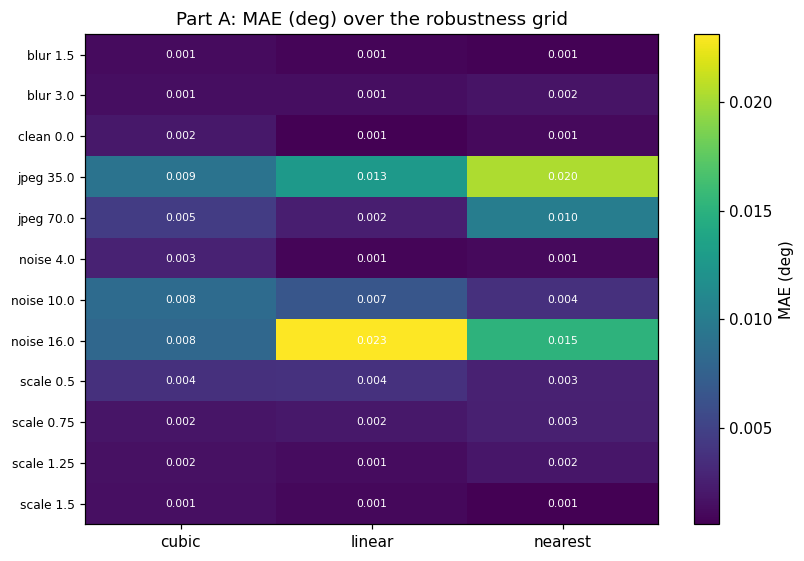

In [10]:
pivot = robust.pivot_table(index=["degradation", "level"], columns="interpolation",
                           values="MAE_deg")
fig, ax = plt.subplots(figsize=(7.5, 5.2))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(["{} {}".format(a, b) for a, b in pivot.index], fontsize=8)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, "{:.3f}".format(pivot.values[i, j]), ha="center", va="center",
                color="w", fontsize=7)
ax.set_title("Part A: MAE (deg) over the robustness grid")
fig.colorbar(im, ax=ax, label="MAE (deg)")
fig.tight_layout()
fig.savefig(aio.output_path("rotation_tests", "robustness_grid.png"), bbox_inches="tight", dpi=110)
plt.show()

## 7. EXPERIMENT ONLY - the long-edge mod-180 cue

Notebook 00 measured the outer region at ~549 x 517 px: the drawing's outer
"square" is about 6% wider than it is tall. A rectangle *does* have a long axis,
so in principle its direction gives the angle modulo **180** deg rather than 90.

**This is a drawing artefact, not physics.** The real port is square (40 x 40 cm),
so a correctly rendered view would carry no such cue. It is measured here to
quantify how strong the artefact is, and it is deliberately **not** used by
`estimate_rotation`.

long-edge cue against truth mod 180:
  MAE      0.0010 deg
  max |err| 0.0030 deg
  fraction within 1 deg : 100.0%

So the artefact is real and quite strong on THIS drawing -- which is exactly
why relying on it would be a trap: it would silently stop working on any
correctly-rendered (square) view of the same physical port.


,true_deg,true_mod180,long_edge_cue_deg,err_mod180_deg
0,0.0,0.0,0.0000,0.0000
1,5.0,5.0,5.0009,0.0009
2,10.0,10.0,9.9986,-0.0014
3,15.0,15.0,15.0001,0.0001
4,20.0,20.0,20.0002,0.0002
5,25.0,25.0,24.9982,-0.0018
6,30.0,30.0,30.0001,0.0001
7,35.0,35.0,35.0019,0.0019
8,40.0,40.0,40.0023,0.0023
9,45.0,45.0,45.0000,0.0000


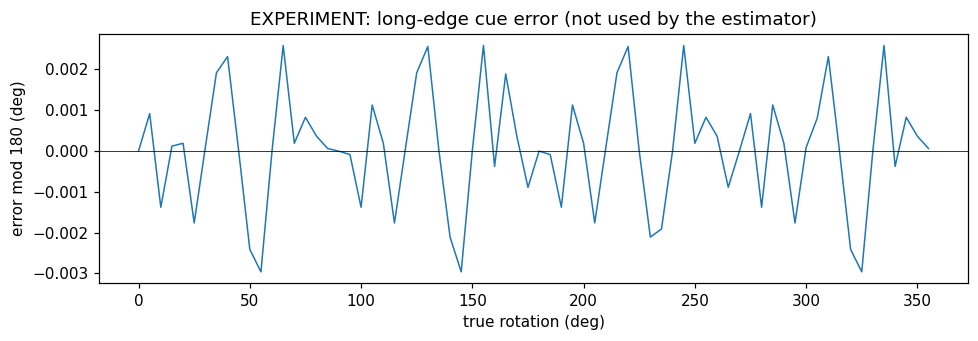

In [11]:
exp = []
for a in np.arange(0.0, 360.0, 5.0):
    d = detect.detect_port(rotation.rotate_image(reference, float(a)))
    est = rotation.estimate_rotation_from_detections(d, ref_det)
    cue = est.long_edge_experiment_deg
    # The cue predicts the angle only mod 180; score it against the truth mod 180.
    err = rotation.wrap180(cue - (a % 180.0))
    if err > 90:
        err -= 180.0
    if err < -90:
        err += 180.0
    exp.append({"true_deg": float(a), "true_mod180": a % 180.0,
                "long_edge_cue_deg": cue, "err_mod180_deg": err})
exp = pd.DataFrame(exp)
print("long-edge cue against truth mod 180:")
print("  MAE      {:.4f} deg".format(exp['err_mod180_deg'].abs().mean()))
print("  max |err| {:.4f} deg".format(exp['err_mod180_deg'].abs().max()))
print("  fraction within 1 deg : {:.1%}".format((exp['err_mod180_deg'].abs() < 1.0).mean()))
print()
print("So the artefact is real and quite strong on THIS drawing -- which is exactly")
print("why relying on it would be a trap: it would silently stop working on any")
print("correctly-rendered (square) view of the same physical port.")
display(exp.head(10).round(4))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(exp["true_deg"], exp["err_mod180_deg"], lw=1.0)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("true rotation (deg)"); ax.set_ylabel("error mod 180 (deg)")
ax.set_title("EXPERIMENT: long-edge cue error (not used by the estimator)")
fig.tight_layout()
fig.savefig(aio.output_path("rotation_tests", "long_edge_experiment.png"),
            bbox_inches="tight", dpi=110)
plt.show()

## 8. Honest failure: no marker, no answer

If the marker cannot be localised the estimator returns
`status='marker_missing'` and `angle_deg = nan`. It does **not** silently fall
back to the mod-90 square cue and present a 1-in-4 guess as an answer.

status      : marker_missing
angle_deg   : nan
confidence  : 0.0
note        : the circular marker was not localised; the square alone only determines the angle modulo 90 deg


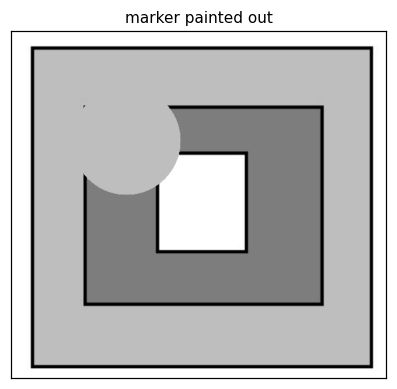

In [12]:
painted = reference.copy()
cv2.circle(painted, tuple(np.round(ref_det.marker_center).astype(int)),
           int(round(ref_det.marker_radius_px * 1.6)), (190, 190, 190), -1)
est = rotation.estimate_rotation(rotation.rotate_image(painted, 33.0), ref_det)
print("status      :", est.status)
print("angle_deg   :", est.angle_deg)
print("confidence  :", est.confidence)
for n in est.notes:
    print("note        :", n)
viz.show(painted, "marker painted out", figsize=(4.4, 4.1)); plt.show()

In [13]:
results.to_csv(aio.output_path("rotation_results.csv"), index=False)
sweep.round(6).to_csv(aio.output_path("rotation_tests", "sweep_1deg.csv"), index=False)
rand.round(6).to_csv(aio.output_path("rotation_tests", "random_200.csv"), index=False)
robust.round(6).to_csv(aio.output_path("rotation_robustness.csv"), index=False)
acc.round(6).to_csv(aio.output_path("rotation_tests", "accuracy_summary.csv"), index=False)
exp.round(6).to_csv(aio.output_path("rotation_tests", "long_edge_experiment.csv"), index=False)
print("wrote outputs/rotation_results.csv, outputs/rotation_robustness.csv and "
      "4 files under outputs/rotation_tests/")

wrote outputs/rotation_results.csv, outputs/rotation_robustness.csv and 4 files under outputs/rotation_tests/


## 9. Limitations

* **The marker must be visible and localisable.** Occlude it and the answer is
  `nan`, by design.
* **Precision is bounded by the marker centroid**, which is what selects the
  90 deg branch. If the marker were much smaller, or much closer to the port
  centre, the coarse estimate would get noisier and the branch selection could
  flip. `config.ROTATION_REFINE_TOL_DEG` (25 deg) is the guard.
* **In-plane rotation only.** This is Part A's question; out-of-plane rotation is
  Parts C/D.
* **No mirroring**, and a single port per image.
* The long-edge cue is an artefact of this particular drawing and is reported as
  an experiment, never used.